In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading (5 Random Stocks, 1 Year of Data)
all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(45) # Different seed for a fresh batch
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 5: 
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        
        # Filter to exactly 1 year of recent data (2025-2026 for instance, or just the last 250 rows)
        df = df.sort_values('Date').reset_index(drop=True)
        if len(df) > 250:
            df = df.tail(250).reset_index(drop=True)
        else:
            continue # Needs to have enough data
            
        df['Symbol'] = symbol
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)
print(f"Loaded {len(data['Symbol'].unique())} stocks for Volatility Squeeze visualization.")


Loaded 5 stocks for Volatility Squeeze visualization.


In [3]:
# 3. Calculate Volatility Squeeze (Bollinger Bands inside Keltner Channels)
# A classic 'Squeeze' happens when volatility drops so low that the Bollinger Bands 
# contract entirely INSIDE the Keltner Channels.

def calculate_squeeze(df):
    df = df.copy()
    
    # 20-Day SMA
    df['SMA_20'] = df['Close'].rolling(20).mean()
    
    # BOLLINGER BANDS (20 days, 2 Std Devs)
    df['StdDev_20'] = df['Close'].rolling(20).std()
    df['BB_Upper'] = df['SMA_20'] + (2 * df['StdDev_20'])
    df['BB_Lower'] = df['SMA_20'] - (2 * df['StdDev_20'])
    
    # KELTNER CHANNELS (20 days, 1.5 ATR)
    # True Range
    df['TR'] = np.maximum(
        df['High'] - df['Low'],
        np.maximum(
            abs(df['High'] - df['Close'].shift(1)),
            abs(df['Low'] - df['Close'].shift(1))
        )
    )
    df['ATR_20'] = df['TR'].rolling(20).mean()
    
    df['KC_Upper'] = df['SMA_20'] + (1.5 * df['ATR_20'])
    df['KC_Lower'] = df['SMA_20'] - (1.5 * df['ATR_20'])
    
    # SQUEEZE LOGIC: BB is inside KC
    df['Squeeze_On'] = (df['BB_Lower'] > df['KC_Lower']) & (df['BB_Upper'] < df['KC_Upper'])
    
    return df

enriched_data = pd.concat([calculate_squeeze(grp) for sym, grp in data.groupby('Symbol')], ignore_index=True)


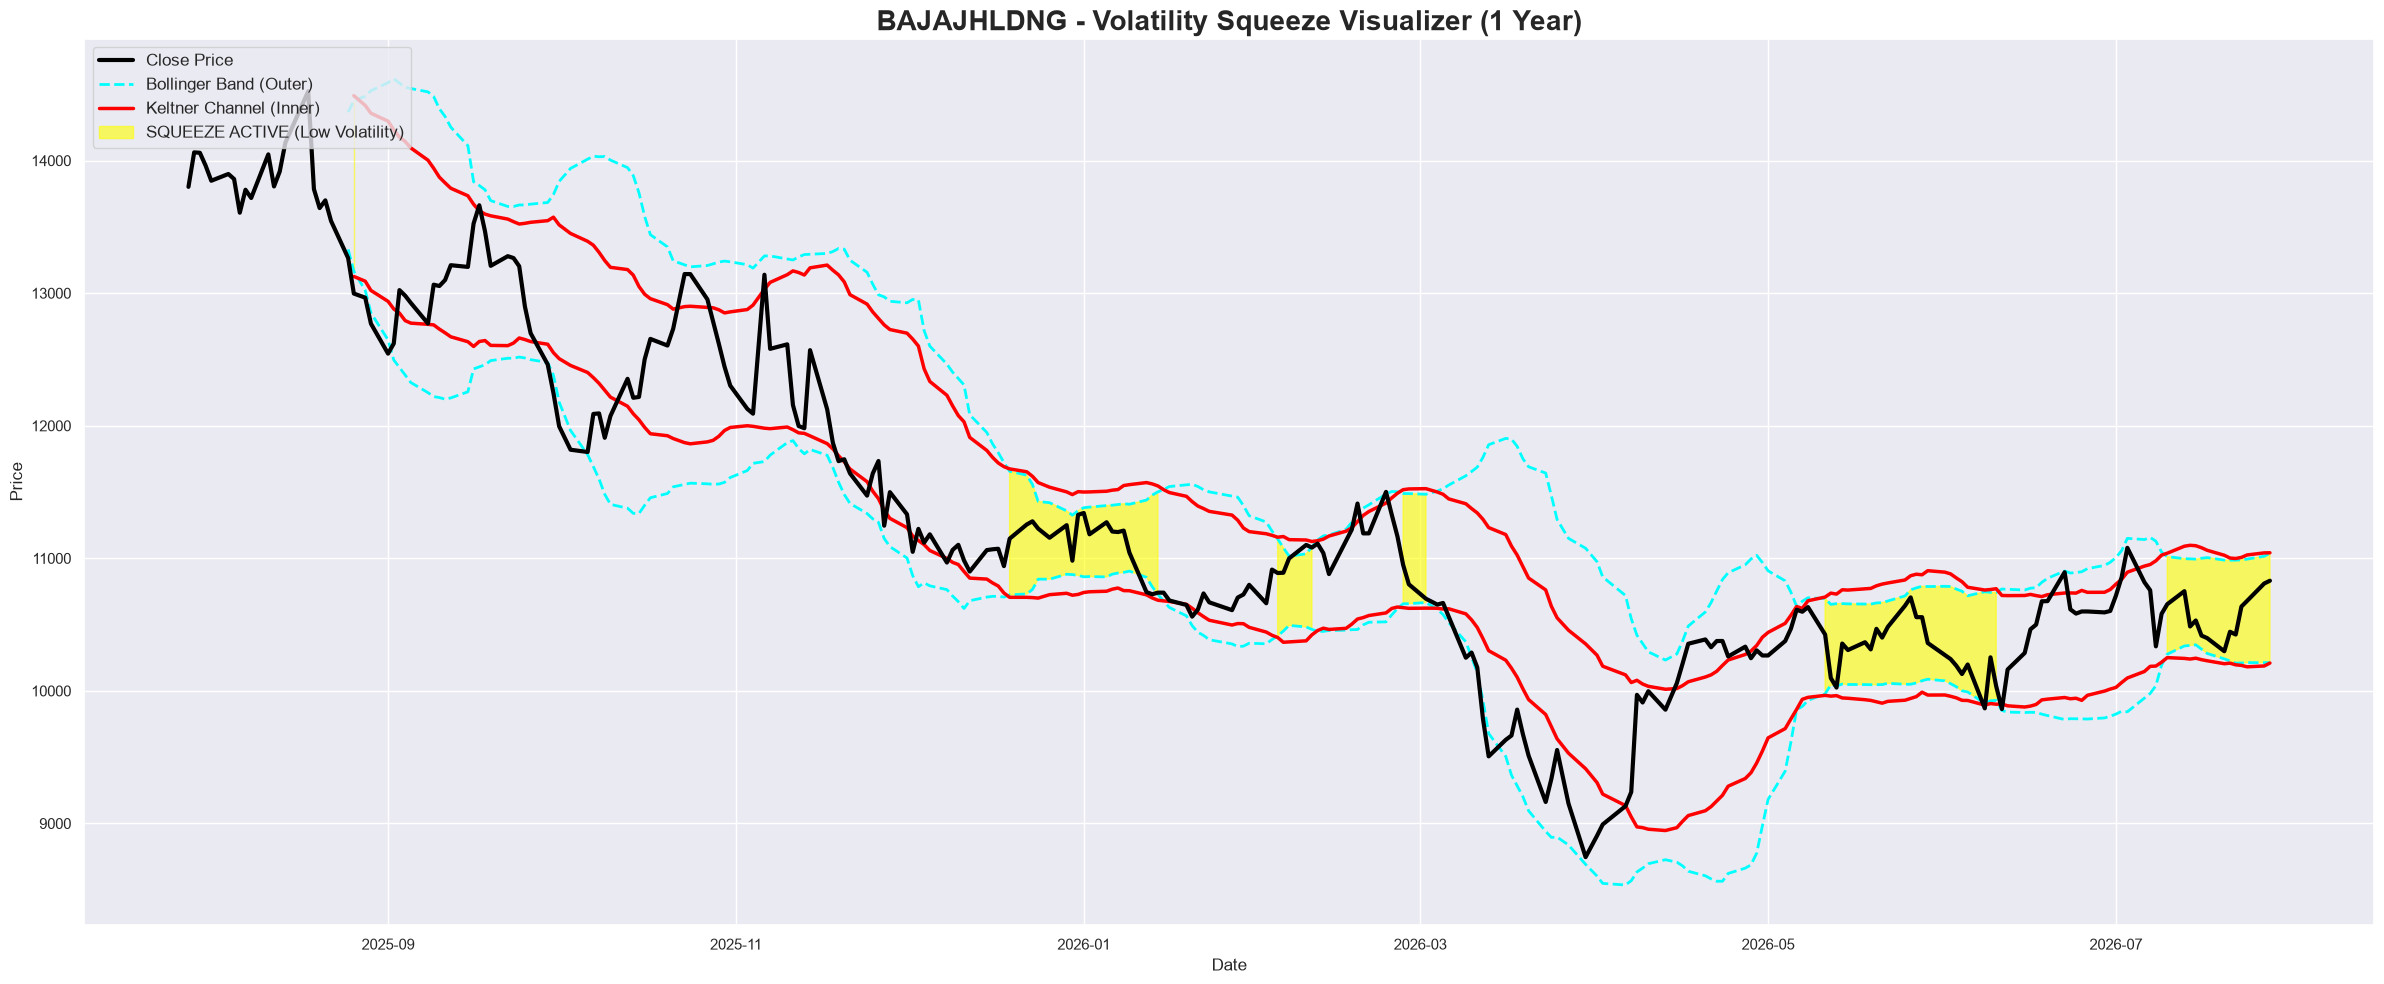

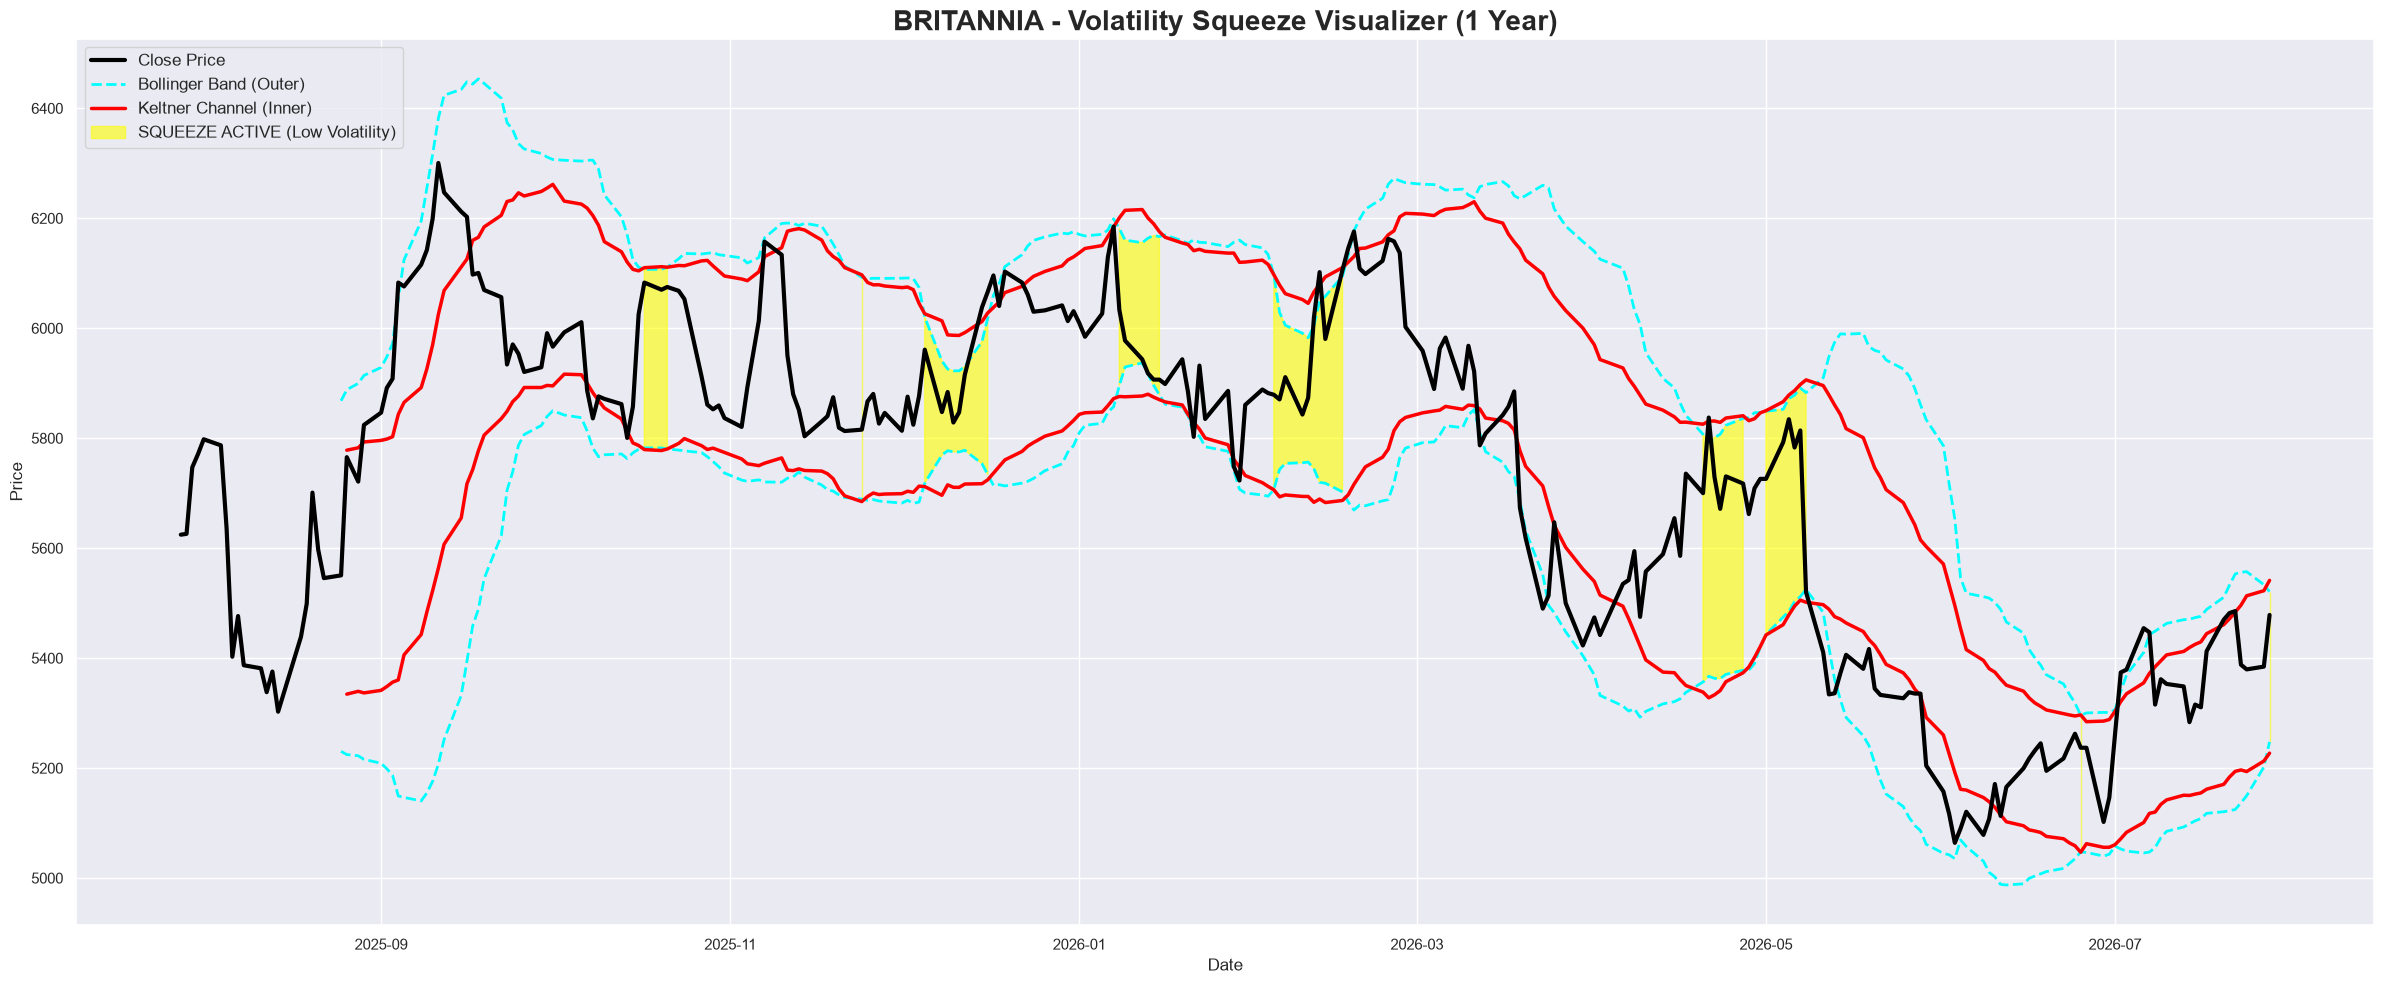

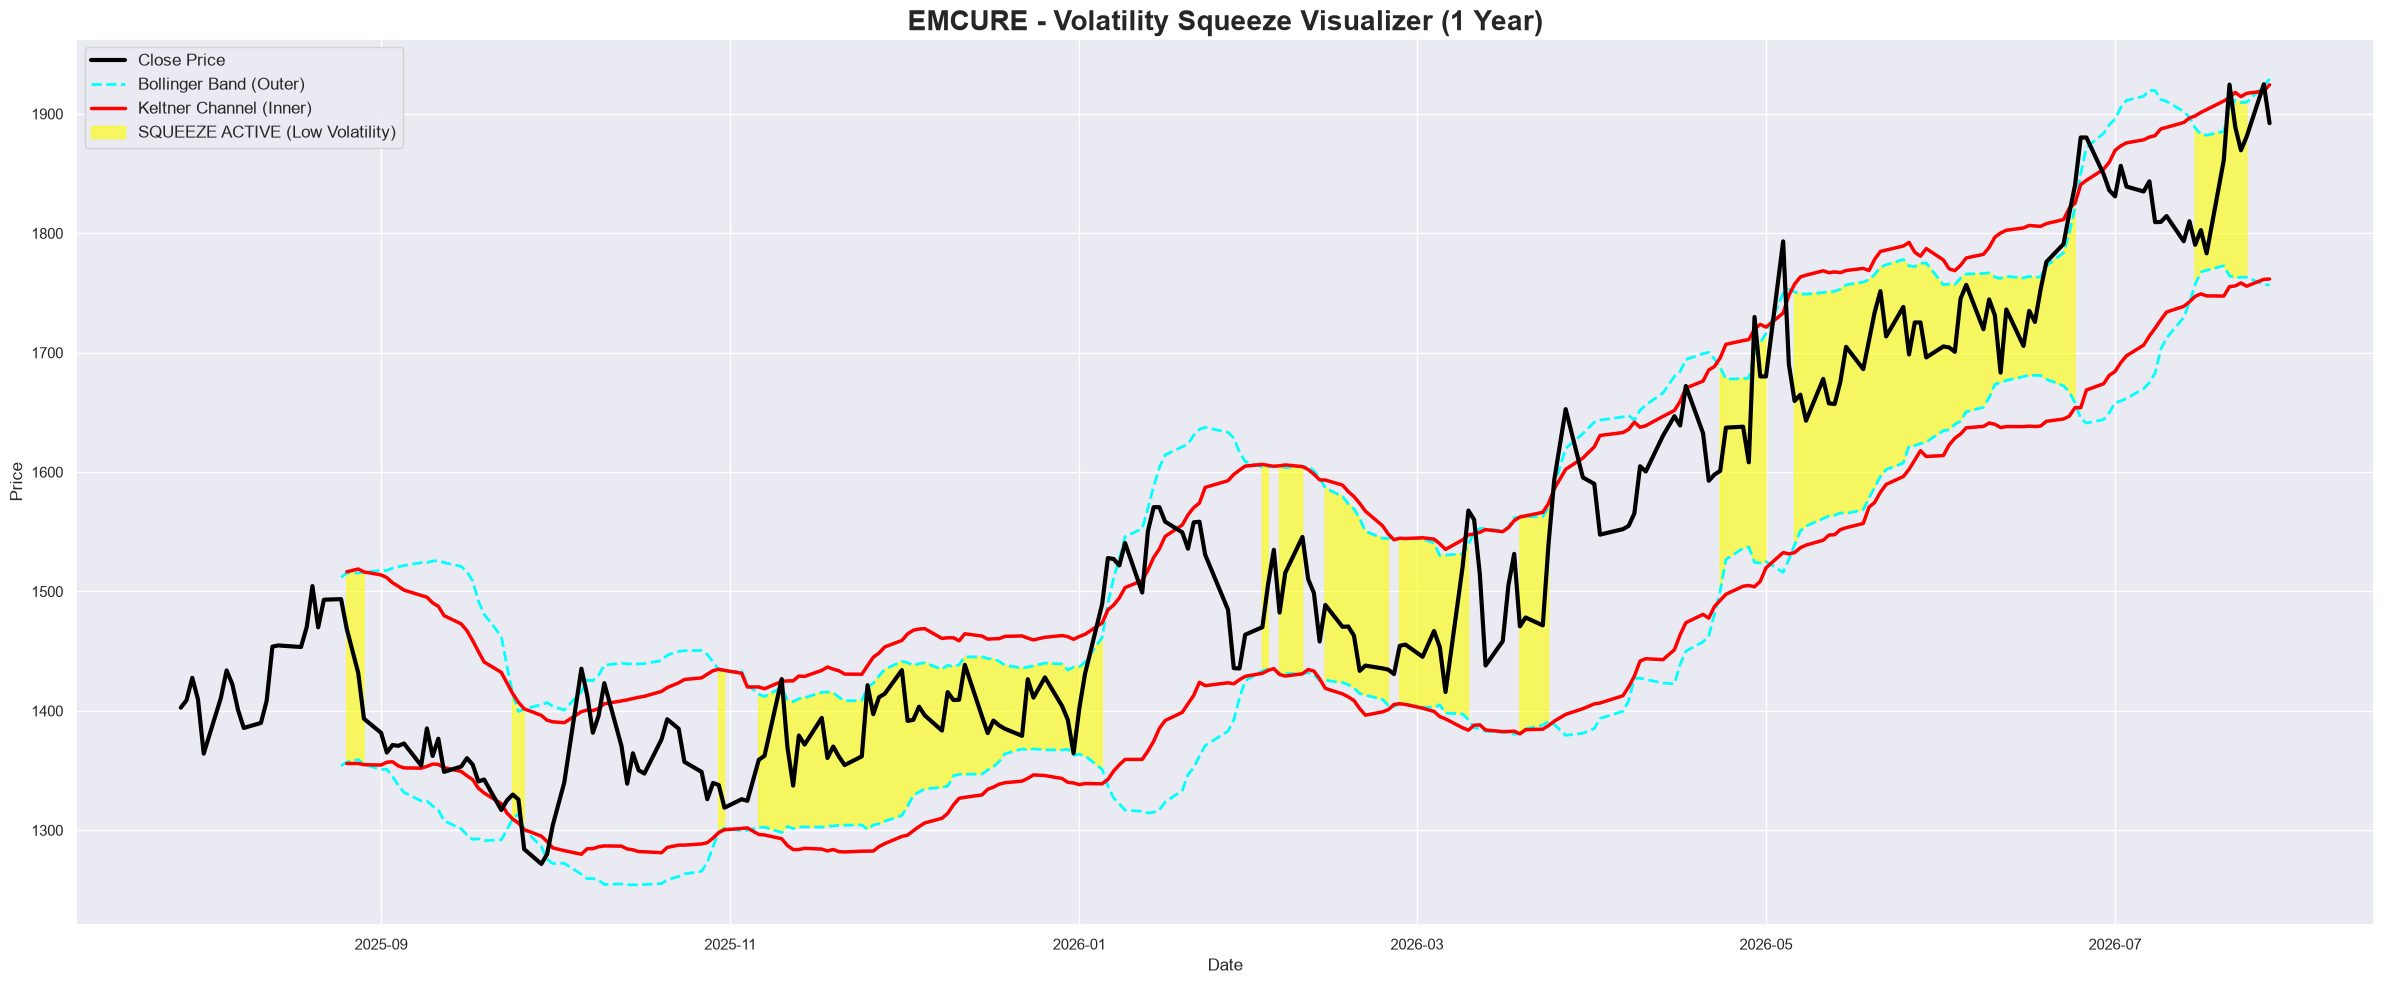

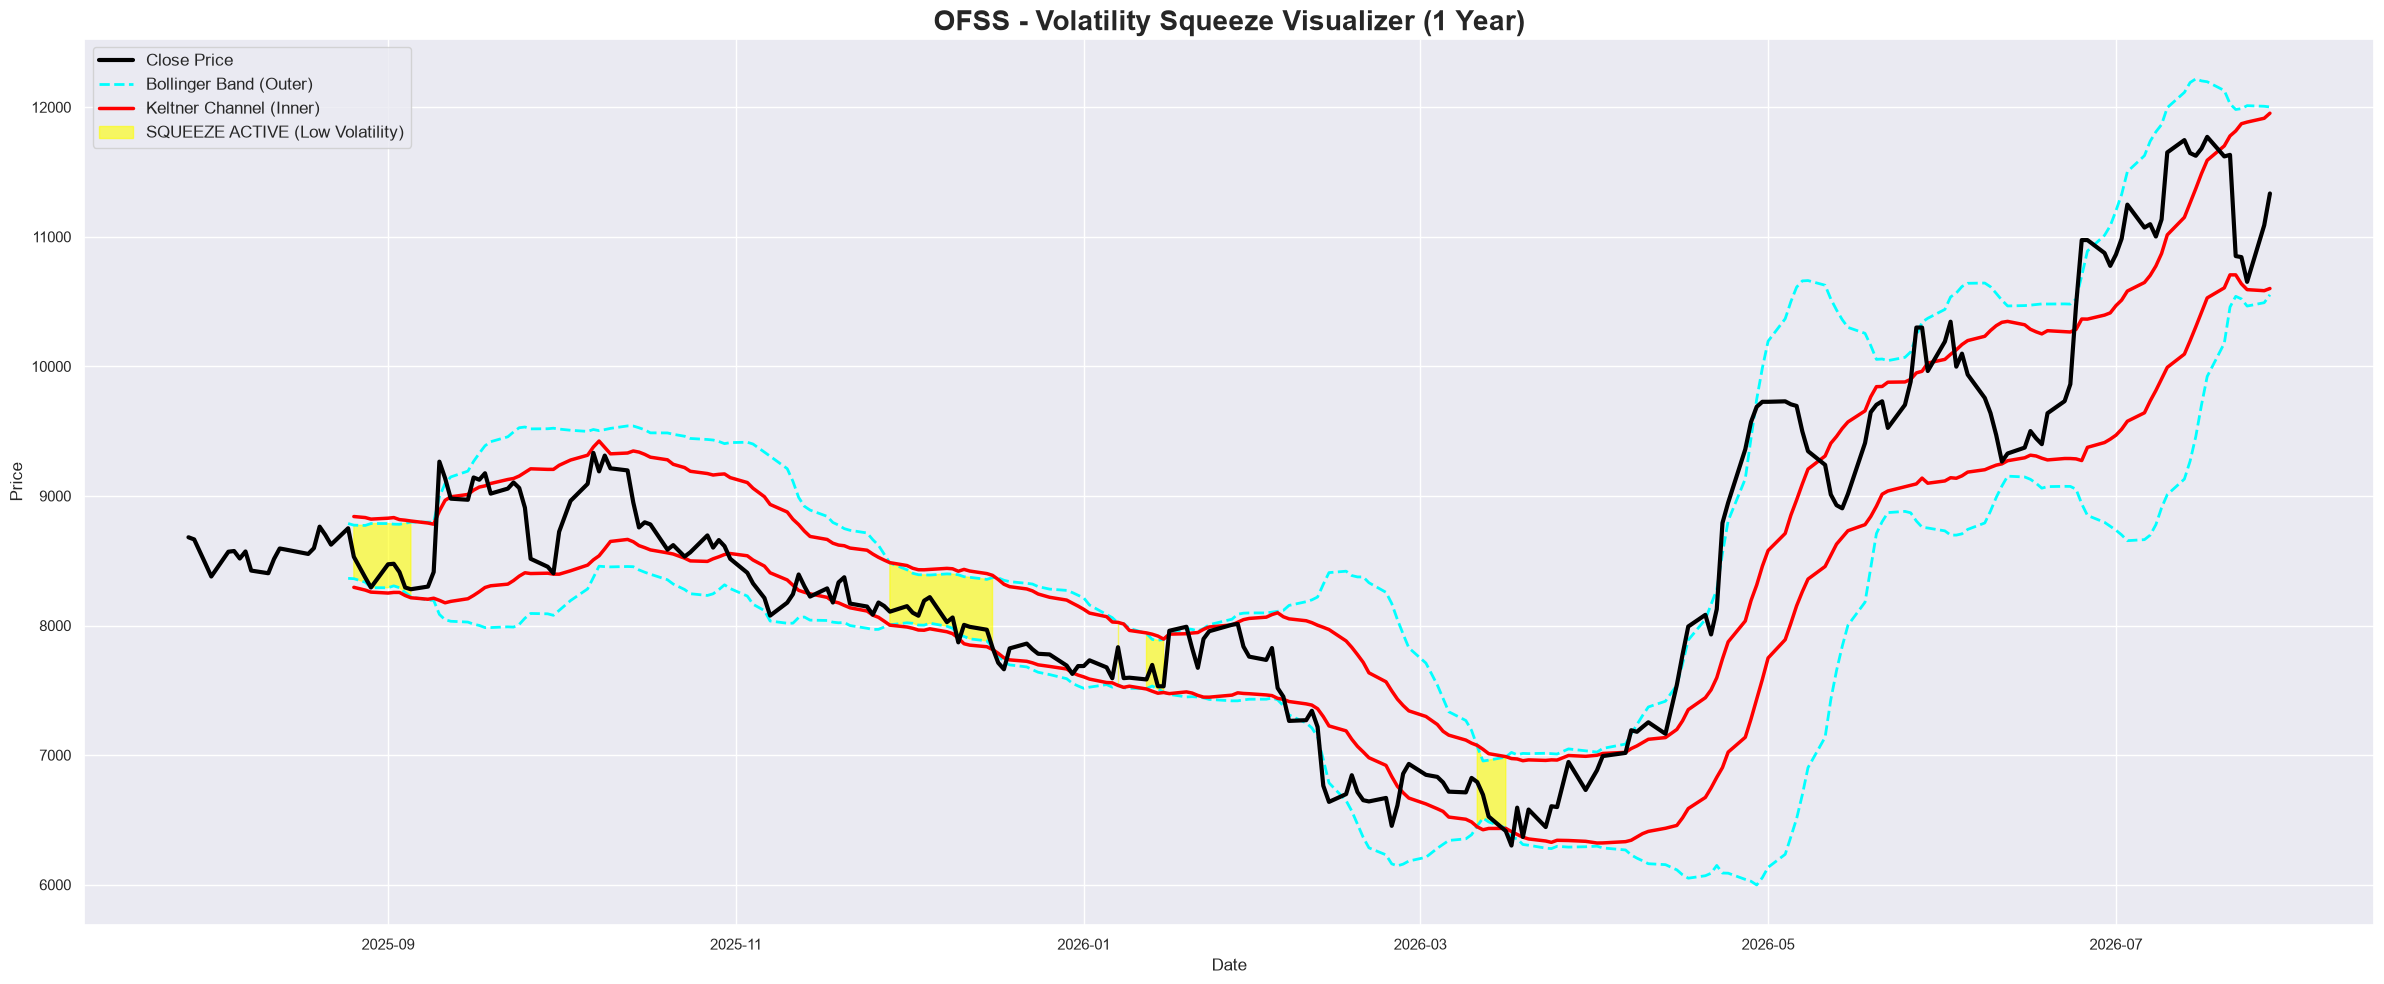

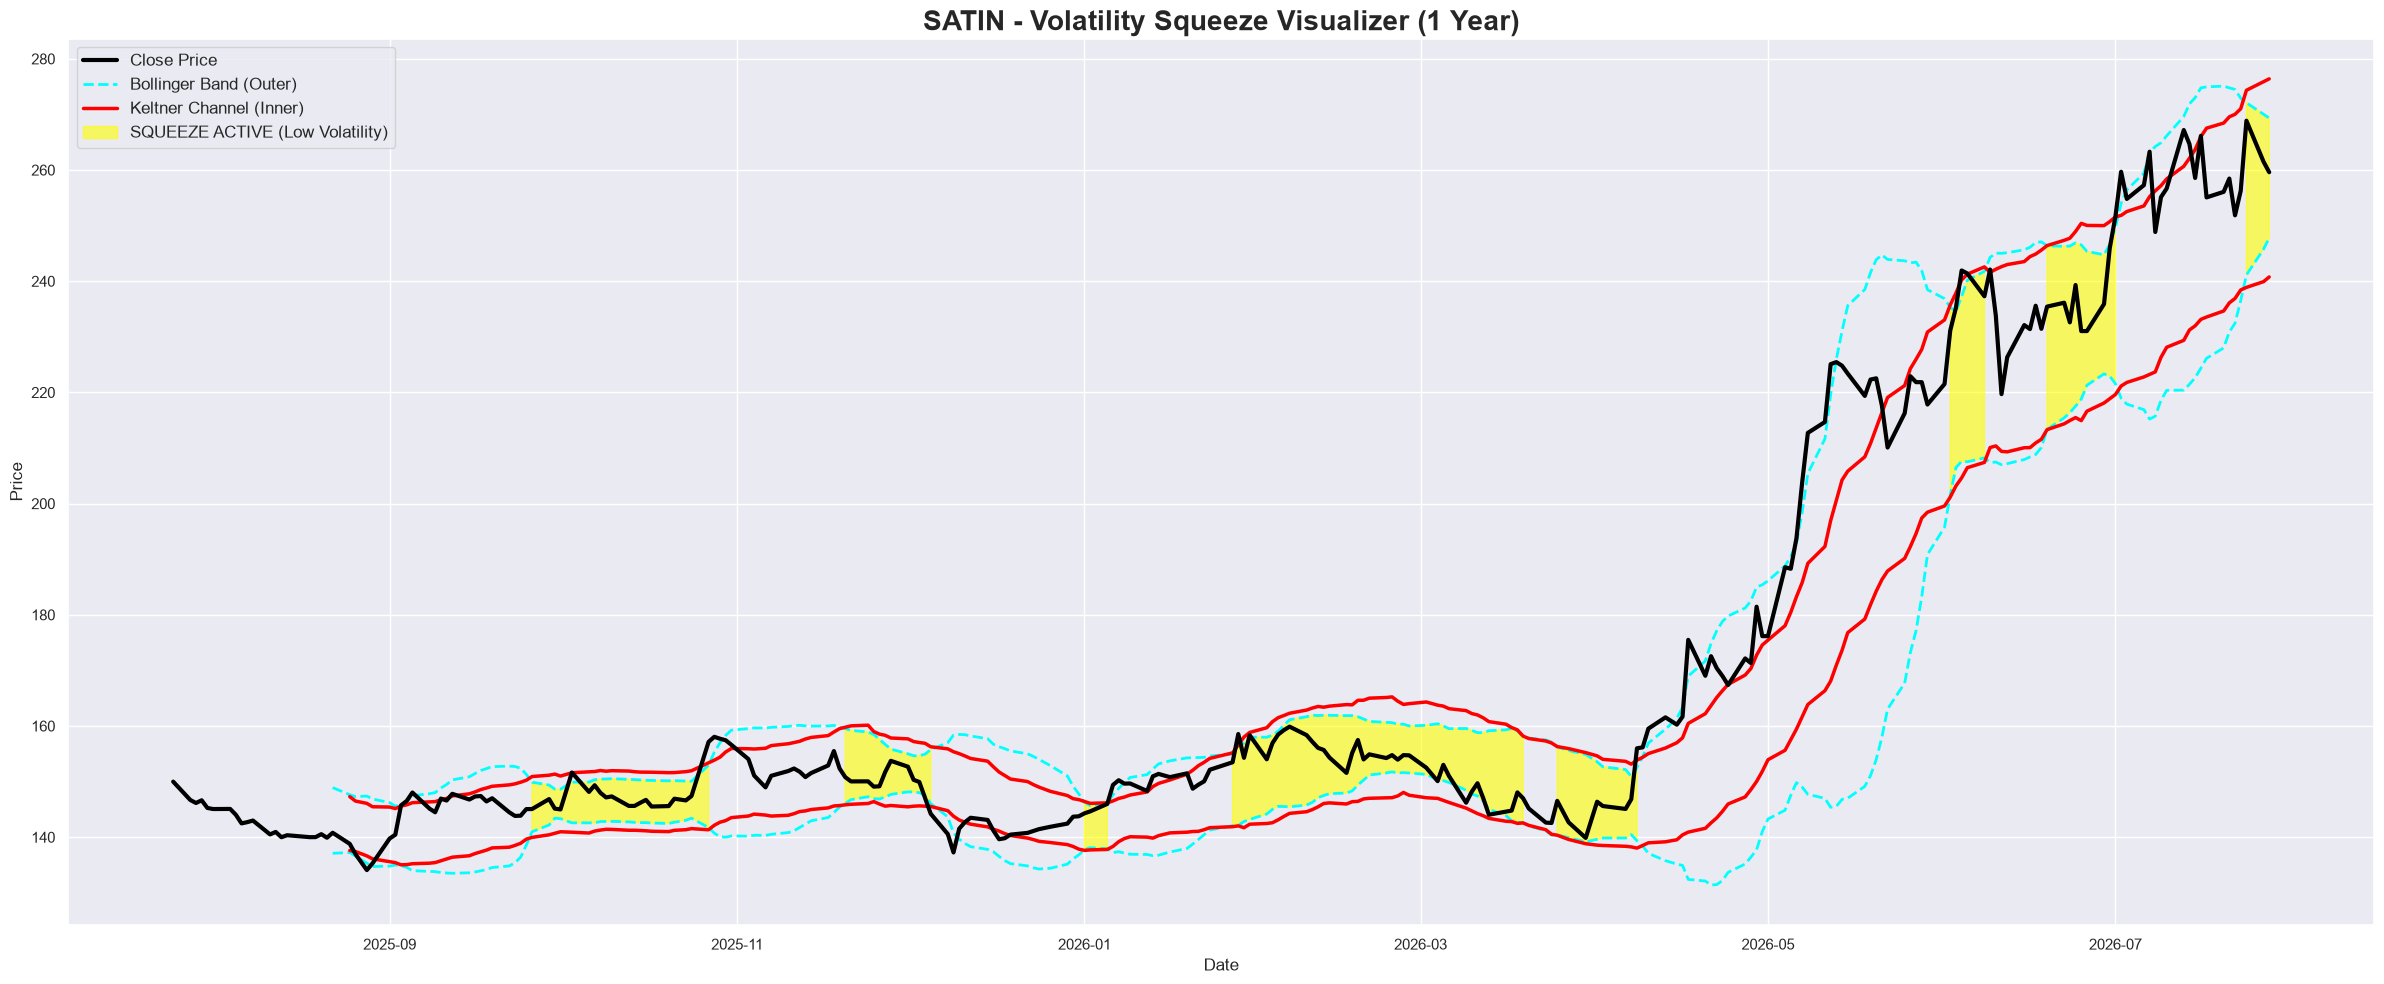

In [4]:
# 4. Plotting the Volatility Squeeze
symbols = enriched_data['Symbol'].unique()

for symbol in symbols:
    df = enriched_data[enriched_data['Symbol'] == symbol].reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(24, 10))
    
    # Plot Price
    ax.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=3, zorder=4)
    
    # Plot Bollinger Bands (Thick & Opaque)
    ax.plot(df['Date'], df['BB_Upper'], color='cyan', linewidth=2, linestyle='--', label='Bollinger Band (Outer)', alpha=1.0)
    ax.plot(df['Date'], df['BB_Lower'], color='cyan', linewidth=2, linestyle='--', alpha=1.0)
    
    # Plot Keltner Channels (Thick & Opaque)
    ax.plot(df['Date'], df['KC_Upper'], color='red', linewidth=2.5, label='Keltner Channel (Inner)', alpha=1.0)
    ax.plot(df['Date'], df['KC_Lower'], color='red', linewidth=2.5, alpha=1.0)
    
    # Shade the background YELLOW when the Squeeze is ON (High Opacity)
    ax.fill_between(df['Date'], df['BB_Lower'], df['BB_Upper'], 
                    where=df['Squeeze_On'], 
                    color='yellow', alpha=0.6, label='SQUEEZE ACTIVE (Low Volatility)')
    
    # Add title and labels
    ax.set_title(f"{symbol} - Volatility Squeeze Visualizer (1 Year)", fontsize=20, fontweight='bold')
    ax.set_ylabel('Price')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()
